**Hotel Booking Cancellation Predictiom**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('booking.csv')

In [ ]:
df.shape

(36285, 17)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36285 entries, 0 to 36284
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Booking_ID                36285 non-null  object 
 1   number of adults          36285 non-null  int64  
 2   number of children        36285 non-null  int64  
 3   number of weekend nights  36285 non-null  int64  
 4   number of week nights     36285 non-null  int64  
 5   type of meal              36285 non-null  object 
 6   car parking space         36285 non-null  int64  
 7   room type                 36285 non-null  object 
 8   lead time                 36285 non-null  int64  
 9   market segment type       36285 non-null  object 
 10  repeated                  36285 non-null  int64  
 11  P-C                       36285 non-null  int64  
 12  P-not-C                   36285 non-null  int64  
 13  average price             36285 non-null  float64
 14  specia

In [ ]:
# Check for missing values
missing_values = df.isnull().sum()
print("Missing values per column:")
print(missing_values)

Missing values per column:
Booking_ID                  0
number of adults            0
number of children          0
number of weekend nights    0
number of week nights       0
type of meal                0
car parking space           0
room type                   0
lead time                   0
market segment type         0
repeated                    0
P-C                         0
P-not-C                     0
average price               0
special requests            0
date of reservation         0
booking status              0
dtype: int64


In [ ]:
# Check for duplicate rows
duplicate_rows = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_rows}")

Number of duplicate rows: 0


### Statistical Summary of Numerical Columns

In [ ]:
# Statistical summary for numerical columns
display(df.describe())

,number of adults,number of children,number of weekend nights,number of week nights,car parking space,lead time,repeated,P-C,P-not-C,average price,special requests
count,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000
mean,1.844839,0.105360,0.810693,2.204602,0.030977,85.239851,0.025630,0.023343,0.153369,103.421636,0.619733
std,0.518813,0.402704,0.870590,1.410946,0.173258,85.938796,0.158032,0.368281,1.753931,35.086469,0.786262
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,0.000000,0.000000,1.000000,0.000000,17.000000,0.000000,0.000000,0.000000,80.300000,0.000000
50%,2.000000,0.000000,1.000000,2.000000,0.000000,57.000000,0.000000,0.000000,0.000000,99.450000,0.000000
75%,2.000000,0.000000,2.000000,3.000000,0.000000,126.000000,0.000000,0.000000,0.000000,120.000000,1.000000
max,4.000000,10.000000,7.000000,17.000000,1.000000,443.000000,1.000000,13.000000,58.000000,540.000000,5.000000


### Statistical Summary of Categorical Columns

In [ ]:
# Statistical summary for categorical columns
display(df.describe(include='object'))

,Booking_ID,type of meal,room type,market segment type,date of reservation,booking status
count,36285,36285,36285,36285,36285,36285
unique,36285,4,7,5,553,2
top,INN36286,Meal Plan 1,Room_Type 1,Online,10/13/2018,Not_Canceled
freq,1,27842,28138,23221,254,24396


### Distribution Plots for Numerical Features

For numerical features, **histograms** are excellent for visualizing the distribution of values, helping to understand their shape, central tendency, and spread. **Box plots** are useful for identifying potential outliers and showing the median, quartiles, and range of the data.

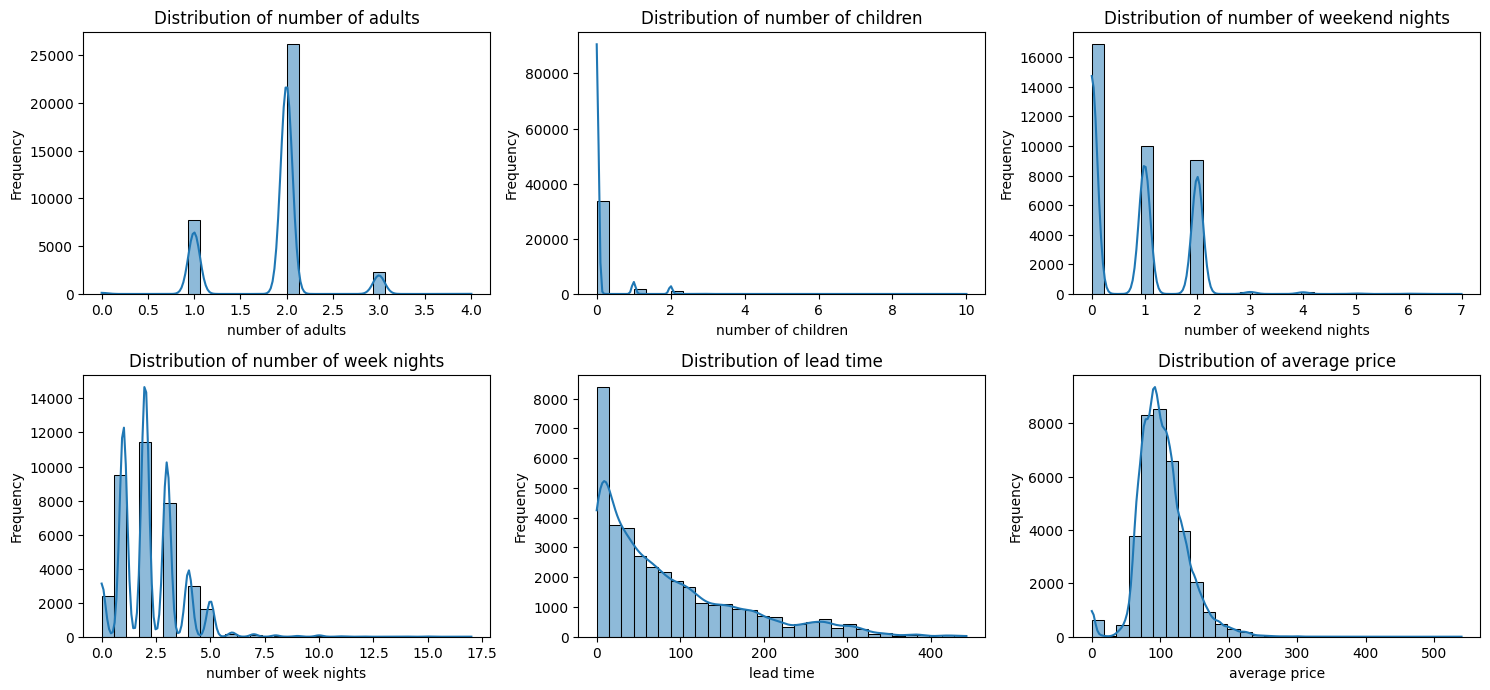

In [ ]:
# Identify numerical columns (excluding Booking_ID as it's an identifier)
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.drop(['P-C', 'P-not-C', 'repeated', 'car parking space', 'special requests'])

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 3, i + 1)  # Adjust grid size based on number of numerical columns
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

#### Interpretation of Numerical Distributions:

*   **`number of adults`**: The distribution shows that most bookings are for 1 or 2 adults, with fewer bookings for 3 or 4 adults. This is a common pattern in hotel bookings.
*   **`number of children`**: The vast majority of bookings have 0 children, indicating that family bookings with children are less frequent.
*   **`number of weekend nights`** and **`number of week nights`**: Both show a distribution heavily skewed towards fewer nights, with 0, 1, or 2 nights being most common, which is typical for short stays.
*   **`lead time`**: This feature is highly skewed to the right, meaning most bookings are made with a short lead time, but there are some bookings made significantly in advance.
*   **`average price`**: The average price shows a relatively normal distribution but with a long tail to the right, indicating some higher-priced bookings.

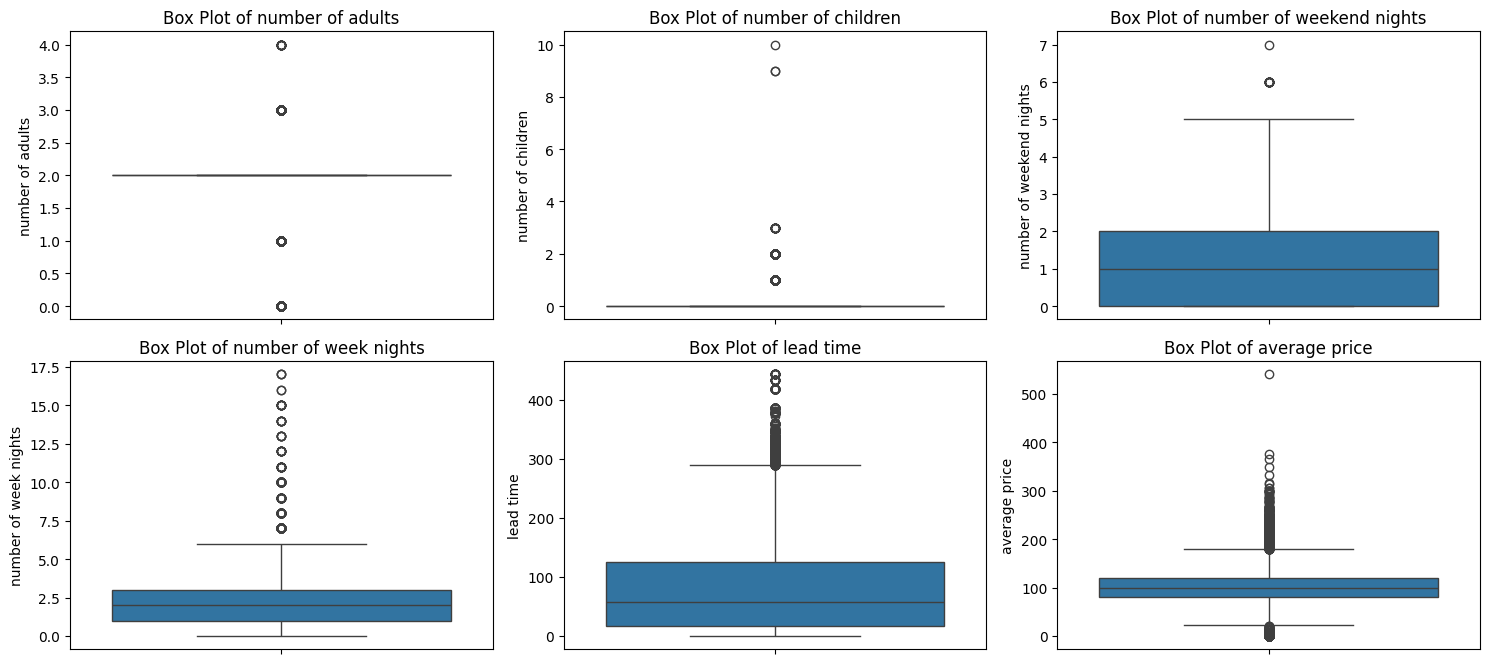

In [ ]:
# Box plots for numerical features to identify outliers
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

#### Interpretation of Box Plots (Outlier Detection):

*   **`number of adults`**, **`number of children`**: The box plots confirm the presence of outliers, especially in `number of children` where values greater than 0 can be considered outliers in the context of the majority of bookings having no children.
*   **`number of weekend nights`** and **`number of week nights`**: Outliers exist for longer stays, which are bookings with an unusually high number of weekend or week nights.
*   **`lead time`**: There are significant outliers indicating bookings made very far in advance.
*   **`average price`**: The box plot clearly shows several outliers at the higher end of the price spectrum, suggesting some premium or special bookings.

The next step in EDA often involves exploring the relationships between variables, such as correlation matrices for numerical features or examining how categorical features relate to the target variable. However, based on the previous context, we moved directly into preprocessing.

### Distribution Plots for Categorical Features

For categorical features, **count plots** (also known as bar plots of counts) are used to visualize the distribution of categories. These plots display the number of occurrences of each category within a variable. They are useful for:

*   **Frequency of Categories:** Understanding which categories are most or least common.
*   **Imbalance:** Identifying if certain categories are heavily over-represented or under-represented, which might be important for modeling tasks.

/tmp/ipykernel_702/2677615986.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order=df[col].value_counts().index, palette='viridis')
/tmp/ipykernel_702/2677615986.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order=df[col].value_counts().index, palette='viridis')
/tmp/ipykernel_702/2677615986.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order=df[col].value_counts().index, palette='viridis')
/tmp/ipykernel_702/2677615986.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is

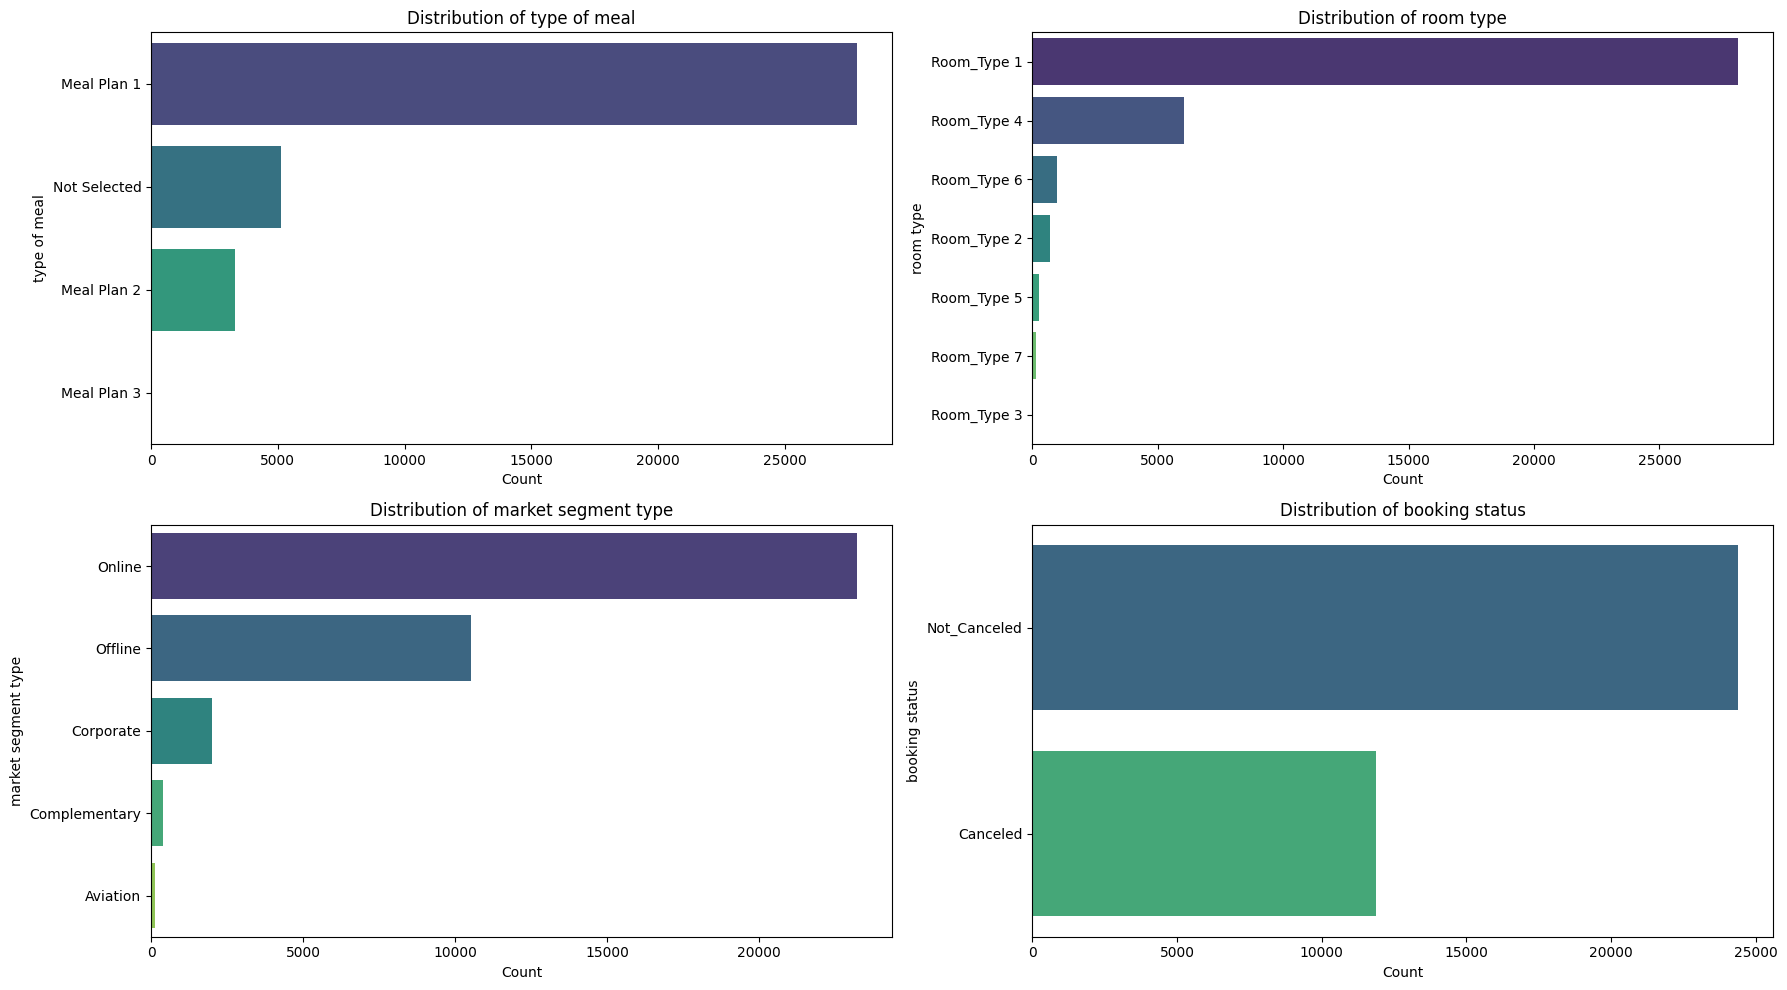

In [ ]:
categorical_cols = ['type of meal', 'room type', 'market segment type', 'booking status']

plt.figure(figsize=(18, 10))
for i, col in enumerate(categorical_cols):
    plt.subplot(2, 2, i + 1) # Adjust grid size as needed
    sns.countplot(y=df[col], order=df[col].value_counts().index, palette='viridis')
    plt.title(f'Distribution of {col}')
    plt.xlabel('Count')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

#### Interpretation of Categorical Distributions:

*   **`type of meal`**: Most bookings opt for 'Meal Plan 1', indicating that this is the standard or most popular choice. 'Meal Plan 2' and 'Not Selected' are less common, and 'Meal Plan 3' is very rare.
*   **`room type`**: 'Room_Type 1' is by far the most frequently booked room type, suggesting it might be the standard or most available option. Other room types are booked significantly less often.
*   **`market segment type`**: 'Online' and 'Offline' bookings dominate, which is expected for hotel reservations. 'Corporate' and 'Complementary' bookings are much less frequent.
*   **`booking status`**: This is our target variable. The plot shows a higher number of 'Not_Canceled' bookings compared to 'Canceled' bookings, indicating a class imbalance. This is an important observation for model training, as imbalanced datasets can lead to models that perform well on the majority class but poorly on the minority class.

## Data Preprocessing

### Encoding Categorical Variables

To prepare the data for machine learning models, categorical variables need to be converted into a numerical format. We will use one-hot encoding for nominal categorical features. First, we'll separate our target variable (`booking status`), and drop irrelevant identifier columns like `Booking_ID` and `date of reservation` which requires specific handling or feature engineering not directly part of standard encoding for nominal categories.

In [ ]:
df_cleaned = df.copy()

# Separate target variable 'booking status' and features
y = df_cleaned['booking status']
X = df_cleaned.drop('booking status', axis=1)

X = X.drop(['Booking_ID', 'date of reservation'], axis=1)

# Identify categorical columns for one-hot encoding
categorical_cols_for_encoding = X.select_dtypes(include='object').columns
print(f"Categorical columns to be one-hot encoded: {list(categorical_cols_for_encoding)}")

# Apply one-hot encoding
X_encoded = pd.get_dummies(X, columns=categorical_cols_for_encoding, drop_first=True)

print(f"\nOriginal features shape: {X.shape}")
print(f"Encoded features shape: {X_encoded.shape}")
print("\nFirst 5 rows of encoded features (X_encoded):")
print(X_encoded.head())

Categorical columns to be one-hot encoded: ['type of meal', 'room type', 'market segment type']

Original features shape: (36285, 14)
Encoded features shape: (36285, 24)

First 5 rows of encoded features (X_encoded):
   number of adults  number of children  number of weekend nights  \
0                 1                   1                         2   
1                 1                   0                         1   
2                 2                   1                         1   
3                 1                   0                         0   
4                 1                   0                         1   

   number of week nights  car parking space  lead time  repeated  P-C  \
0                      5                  0        224         0    0   
1                      3                  0          5         0    0   
2                      3                  0          1         0    0   
3                      2                  0        211         0    0   
4  

### Feature Scaling (Revisited)

As previously explained, feature scaling is crucial for machine learning algorithms. We will re-apply `StandardScaler` to ensure numerical features have a mean of 0 and a standard deviation of 1.

In [ ]:
from sklearn.preprocessing import StandardScaler

# Identify numerical columns in X_encoded (excluding the newly created one-hot encoded columns which are already binary/numerical)
numerical_cols_to_scale = X_encoded.select_dtypes(include=['int64', 'float64']).columns

# Initialize the StandardScaler
scaler = StandardScaler()

# Apply StandardScaler to the numerical columns
X_encoded[numerical_cols_to_scale] = scaler.fit_transform(X_encoded[numerical_cols_to_scale])

print("Numerical features after scaling (first 5 rows):")
print(X_encoded[numerical_cols_to_scale].head())
print("\nDescriptive statistics of scaled numerical features:")
print(X_encoded[numerical_cols_to_scale].describe())

Numerical features after scaling (first 5 rows):
   number of adults  number of children  number of weekend nights  \
0         -1.628431            2.221609                  1.366111   
1         -1.628431           -0.261636                  0.217450   
2          0.299073            2.221609                  0.217450   
3         -1.628431           -0.261636                 -0.931212   
4         -1.628431           -0.261636                  0.217450   

   number of week nights  car parking space  lead time  repeated       P-C  \
0               1.981250          -0.178794   1.614661 -0.162187 -0.063385   
1               0.563741          -0.178794  -0.933699 -0.162187 -0.063385   
2               0.563741          -0.178794  -0.980244 -0.162187 -0.063385   
3              -0.145013          -0.178794   1.463389 -0.162187 -0.063385   
4              -0.145013          -0.178794  -0.433336 -0.162187 -0.063385   

    P-not-C  average price  special requests  
0 -0.087444      -0.

### Feature Selection

Feature selection is the process of selecting a subset of relevant features for use in model construction. It helps in reducing overfitting, improving accuracy, and reducing training time. We will use `SelectKBest` with `f_classif` (for classification tasks) to select the top `k` features based on their scores.

Top 10 features selected:
Index(['number of adults', 'number of week nights', 'car parking space',
       'lead time', 'repeated', 'average price', 'special requests',
       'type of meal_Meal Plan 2', 'market segment type_Corporate',
       'market segment type_Online'],
      dtype='object')

Feature Scores:


,Feature,Score
5,lead time,8636.973616
10,special requests,2483.189449
9,average price,751.316938
21,market segment type_Corporate,469.163060
6,repeated,422.416433
23,market segment type_Online,415.159896
3,number of week nights,315.345043
0,number of adults,275.275344
11,type of meal_Meal Plan 2,273.319719
4,car parking space,271.485302


/tmp/ipykernel_702/3214926558.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Score', y='Feature', data=feature_scores.head(k), palette='viridis')


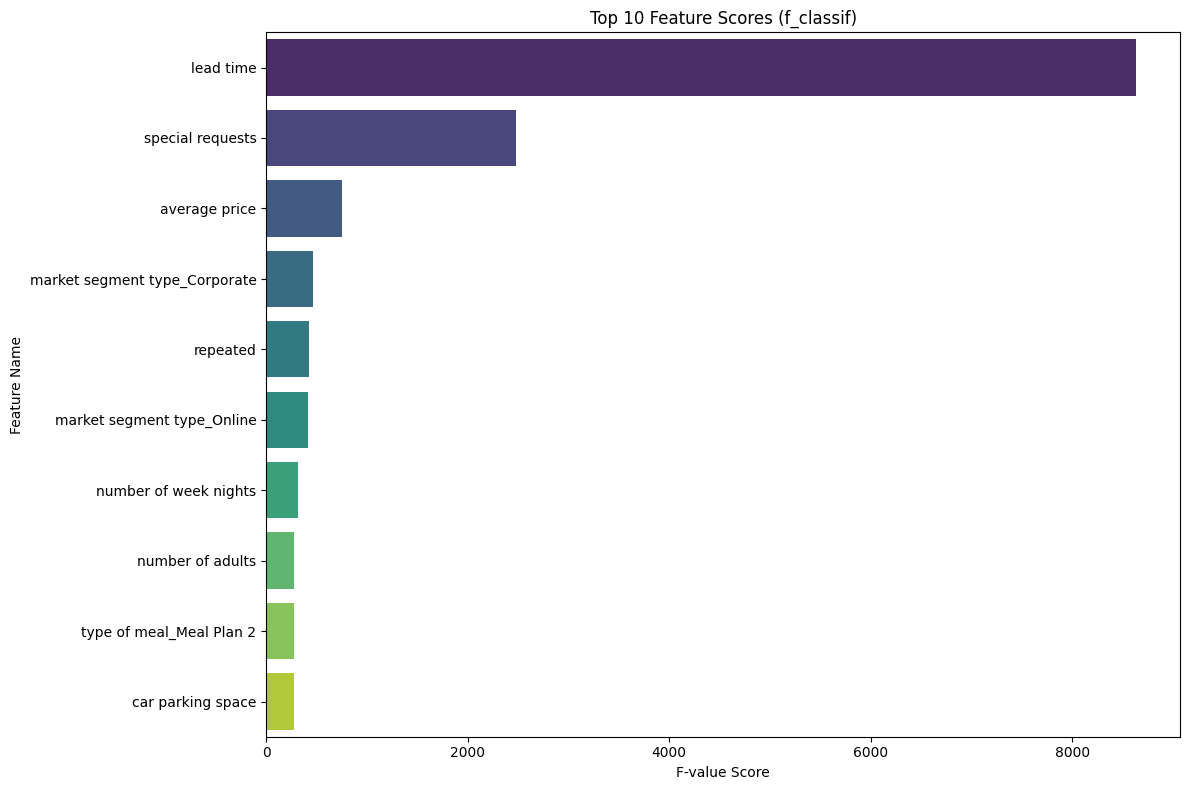

In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif
import matplotlib.pyplot as plt
import seaborn as sns

# Convert y to numerical if it's not already, as f_classif expects numerical target
# Assuming 'Not_Canceled' is 0 and 'Canceled' is 1 for binary classification
y_numerical = y.apply(lambda x: 1 if x == 'Canceled' else 0)

# Initialize SelectKBest with f_classif. We can start by selecting a reasonable number of features, e.g., 10
# The number of features can be tuned later.
k = 10 # Number of top features to select
selector = SelectKBest(f_classif, k=k)

# Fit the selector to the encoded features and the numerical target
selector.fit(X_encoded, y_numerical)

# Get the selected feature names
selected_features = X_encoded.columns[selector.get_support()]

# Get the scores of all features
feature_scores = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Score': selector.scores_
}).sort_values(by='Score', ascending=False)

print(f"Top {k} features selected:")
print(selected_features)

print("\nFeature Scores:")
display(feature_scores)

# Optional: Visualize feature scores
plt.figure(figsize=(12, 8))
sns.barplot(x='Score', y='Feature', data=feature_scores.head(k), palette='viridis')
plt.title(f'Top {k} Feature Scores (f_classif)')
plt.xlabel('F-value Score')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()

### Split Features and Target & Train-Test Split

Now that we have selected the most relevant features, we will create our final feature set `X_selected` using these features. Then, we will split the data into training and testing sets to evaluate our model's performance on unseen data. A common split ratio is 80% for training and 20% for testing.

In [ ]:
from sklearn.model_selection import train_test_split

# Create the final feature set using only the selected features
X_selected = X_encoded[selected_features]

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X_selected, y_numerical, test_size=0.2, random_state=42, stratify=y_numerical)

print(f"Shape of X_selected: {X_selected.shape}")
print(f"Shape of y_numerical: {y_numerical.shape}")
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

print("\nFirst 5 rows of X_train:")
display(X_train.head())
print("\nFirst 5 values of y_train:")
display(y_train.head())

Shape of X_selected: (36285, 10)
Shape of y_numerical: (36285,)
Shape of X_train: (29028, 10)
Shape of X_test: (7257, 10)
Shape of y_train: (29028,)
Shape of y_test: (7257,)

First 5 rows of X_train:


,number of adults,number of week nights,car parking space,lead time,repeated,average price,special requests,type of meal_Meal Plan 2,market segment type_Corporate,market segment type_Online
31860,-1.628431,-0.853767,-0.178794,-0.863881,-0.162187,-1.170029,0.483646,False,False,True
1141,0.299073,-0.853767,-0.178794,0.427754,-0.162187,0.101988,0.483646,True,False,False
246,0.299073,0.563741,5.593034,-0.084245,-0.162187,0.053536,0.483646,False,False,True
26640,0.299073,-0.145013,-0.178794,0.544117,-0.162187,1.413053,1.755504,False,False,True
5783,0.299073,-0.853767,-0.178794,-0.805699,-0.162187,-0.810057,-0.788212,False,True,False



First 5 values of y_train:


,booking status
31860,0
1141,0
246,0
26640,0
5783,0


## Model Training

Now that the data has been preprocessed and split into training and testing sets, we can proceed with training several machine learning models. We will implement:

1.  **Logistic Regression**
2.  **Decision Tree**
3.  **Random Forest**
4.  **K-Nearest Neighbors (KNN)**

For each model, we will train it on the `X_train` and `y_train` data and then evaluate its performance using relevant metrics.

### 1. Logistic Regression

Logistic Regression is a linear model used for binary classification. It estimates the probability of an instance belonging to a particular class. Despite its name, it is a classification algorithm rather than a regression algorithm.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Initialize and train the Logistic Regression model
log_reg_model = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' solver is good for small datasets and handles L1/L2 penalties
log_reg_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_log_reg = log_reg_model.predict(X_test)
y_proba_log_reg = log_reg_model.predict_proba(X_test)[:, 1] # Probabilities for the positive class

# Evaluate the model
print("--- Logistic Regression Model Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_log_reg):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_log_reg):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_log_reg):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_log_reg):.4f}")
print(f"ROC AUC Score: {roc_auc_score(y_test, y_proba_log_reg):.4f}")

--- Logistic Regression Model Evaluation ---
Accuracy: 0.8057
Precision: 0.7526
Recall: 0.6064
F1-Score: 0.6716
ROC AUC Score: 0.8670


### 2. Decision Tree

A Decision Tree is a non-parametric supervised learning algorithm that is used for both classification and regression tasks. It works by splitting the data into subsets based on feature values, creating a tree-like structure of decisions.

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Initialize and train the Decision Tree model
dec_tree_model = DecisionTreeClassifier(random_state=42)
dec_tree_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_dec_tree = dec_tree_model.predict(X_test)
y_proba_dec_tree = dec_tree_model.predict_proba(X_test)[:, 1]

# Evaluate the model
print("--- Decision Tree Model Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dec_tree):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_dec_tree):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_dec_tree):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_dec_tree):.4f}")
print(f"ROC AUC Score: {roc_auc_score(y_test, y_proba_dec_tree):.4f}")

--- Decision Tree Model Evaluation ---
Accuracy: 0.8596
Precision: 0.7842
Recall: 0.7885
F1-Score: 0.7863
ROC AUC Score: 0.8449


### 3. Random Forest

Random Forest is an ensemble learning method for classification, regression and other tasks that operates by constructing a multitude of decision trees at training time and outputting the class that is the mode of the classes (classification) or mean prediction (regression) of the individual trees.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train the Random Forest model
rand_forest_model = RandomForestClassifier(random_state=42)
rand_forest_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rand_forest = rand_forest_model.predict(X_test)
y_proba_rand_forest = rand_forest_model.predict_proba(X_test)[:, 1]

# Evaluate the model
print("--- Random Forest Model Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rand_forest):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rand_forest):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_rand_forest):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_rand_forest):.4f}")
print(f"ROC AUC Score: {roc_auc_score(y_test, y_proba_rand_forest):.4f}")

--- Random Forest Model Evaluation ---
Accuracy: 0.8859
Precision: 0.8507
Recall: 0.7906
F1-Score: 0.8195
ROC AUC Score: 0.9427


### 4. K-Nearest Neighbors (KNN)

K-Nearest Neighbors is a non-parametric, lazy learning algorithm used for both classification and regression. In KNN classification, an object is classified by a majority vote of its neighbors, with the object being assigned to the class most common among its k nearest neighbors.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# Initialize and train the K-Nearest Neighbors model
knn_model = KNeighborsClassifier(n_neighbors=5) # n_neighbors is a hyperparameter to tune
knn_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_knn = knn_model.predict(X_test)
y_proba_knn = knn_model.predict_proba(X_test)[:, 1]

# Evaluate the model
print("--- K-Nearest Neighbors Model Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_knn):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_knn):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_knn):.4f}")
print(f"ROC AUC Score: {roc_auc_score(y_test, y_proba_knn):.4f}")

--- K-Nearest Neighbors Model Evaluation ---
Accuracy: 0.8663
Precision: 0.8194
Recall: 0.7595
F1-Score: 0.7883
ROC AUC Score: 0.9120


## Section 7: Hyperparameter Tuning

Hyperparameter tuning is the process of finding the optimal set of hyperparameters for a machine learning model. `GridSearchCV` systematically works through multiple combinations of parameter tunes, cross-validating each combination to determine which one performs best. It's an exhaustive search that can be computationally intensive but often yields good results.

### 1. Hyperparameter Tuning for Decision Tree

We'll tune parameters like `max_depth` (the maximum depth of the tree) and `min_samples_split` (the minimum number of samples required to split an internal node).

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

# Define the parameter grid for Decision Tree
dt_param_grid = {
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 10, 20],
    'min_samples_leaf': [1, 5, 10]
}

# Initialize GridSearchCV for Decision Tree
dt_grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42), dt_param_grid, cv=5, scoring='roc_auc', n_jobs=-1)

# Fit GridSearchCV to the training data
dt_grid_search.fit(X_train, y_train)

# Print the best parameters and best score
print("--- Decision Tree Best Parameters and Score ---")
print(f"Best Parameters: {dt_grid_search.best_params_}")
print(f"Best ROC AUC Score: {dt_grid_search.best_score_:.4f}")

# Store the best model
best_dt_model = dt_grid_search.best_estimator_

--- Decision Tree Best Parameters and Score ---
Best Parameters: {'max_depth': 10, 'min_samples_leaf': 5, 'min_samples_split': 2}
Best ROC AUC Score: 0.9131


### 2. Hyperparameter Tuning for Random Forest

For Random Forest, we'll tune parameters such as `n_estimators` (number of trees in the forest), `max_depth`, and `min_samples_split`.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Define the parameter grid for Random Forest
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 10]
}

# Initialize GridSearchCV for Random Forest
rf_grid_search = GridSearchCV(RandomForestClassifier(random_state=42), rf_param_grid, cv=5, scoring='roc_auc', n_jobs=-1)

# Fit GridSearchCV to the training data
rf_grid_search.fit(X_train, y_train)

# Print the best parameters and best score
print("--- Random Forest Best Parameters and Score ---")
print(f"Best Parameters: {rf_grid_search.best_params_}")
print(f"Best ROC AUC Score: {rf_grid_search.best_score_:.4f}")

# Store the best model
best_rf_model = rf_grid_search.best_estimator_

--- Random Forest Best Parameters and Score ---
Best Parameters: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 300}
Best ROC AUC Score: 0.9393


### 3. Hyperparameter Tuning for K-Nearest Neighbors (KNN)

For KNN, the main hyperparameter to tune is `n_neighbors` (number of neighbors to consider).

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# Define the parameter grid for KNN
knn_param_grid = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance']
}

# Initialize GridSearchCV for KNN
knn_grid_search = GridSearchCV(KNeighborsClassifier(), knn_param_grid, cv=5, scoring='roc_auc', n_jobs=-1)

# Fit GridSearchCV to the training data
knn_grid_search.fit(X_train, y_train)

# Print the best parameters and best score
print("--- K-Nearest Neighbors Best Parameters and Score ---")
print(f"Best Parameters: {knn_grid_search.best_params_}")
print(f"Best ROC AUC Score: {knn_grid_search.best_score_:.4f}")

# Store the best model
best_knn_model = knn_grid_search.best_estimator_

--- K-Nearest Neighbors Best Parameters and Score ---
Best Parameters: {'n_neighbors': 9, 'weights': 'distance'}
Best ROC AUC Score: 0.9180


## Section 8: Model Evaluation

After training and hyperparameter tuning, it's crucial to evaluate the performance of our models on the unseen test set (`X_test`). This section will assess each model using a comprehensive suite of metrics and visualizations:

*   **Accuracy**
*   **Precision**
*   **Recall**
*   **F1-score**
*   **ROC AUC Score**
*   **Confusion Matrix**
*   **Classification Report**
*   **ROC Curve**

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_model(model, X_test, y_test, model_name):
    print(f"### --- {model_name} Model Evaluation ---")

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"ROC AUC Score: {roc_auc:.4f}")
    print("\n")

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Not Canceled', 'Canceled'],
                yticklabels=['Not Canceled', 'Canceled'])
    plt.title(f'{model_name} Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
    print("\n")

    # Classification Report
    print(f"Classification Report for {model_name}:\n")
    print(classification_report(y_test, y_pred))
    print("\n")

    # ROC Curve
    fpr, tpr, thresholds = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'{model_name} Receiver Operating Characteristic')
    plt.legend(loc="lower right")
    plt.show()
    print("\n" + "="*70 + "\n")

### 1. Logistic Regression Evaluation (Initial Model)

We will evaluate the Logistic Regression model that was trained in Section 6, as we did not perform hyperparameter tuning for it in Section 7.

### --- Logistic Regression (Initial) Model Evaluation ---
Accuracy: 0.8057
Precision: 0.7526
Recall: 0.6064
F1-Score: 0.6716
ROC AUC Score: 0.8670




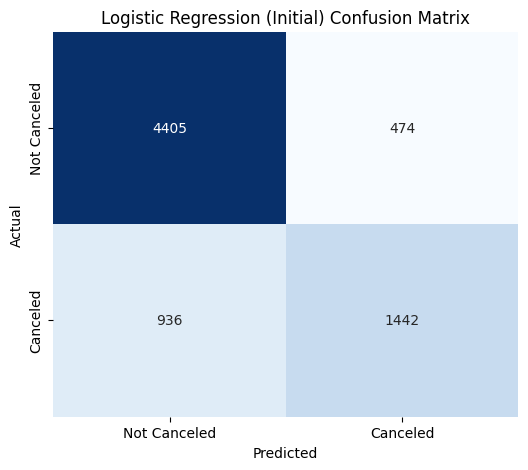



Classification Report for Logistic Regression (Initial):

              precision    recall  f1-score   support

           0       0.82      0.90      0.86      4879
           1       0.75      0.61      0.67      2378

    accuracy                           0.81      7257
   macro avg       0.79      0.75      0.77      7257
weighted avg       0.80      0.81      0.80      7257





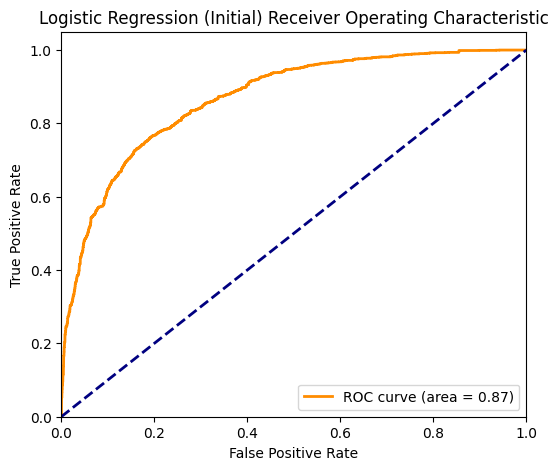

In [ ]:
# Evaluate the initial Logistic Regression model
evaluate_model(log_reg_model, X_test, y_test, "Logistic Regression (Initial)")

### 2. Decision Tree Evaluation (Tuned Model)

Here we evaluate the Decision Tree model with the best hyperparameters found using `GridSearchCV`.

### --- Decision Tree (Tuned) Model Evaluation ---
Accuracy: 0.8691
Precision: 0.8202
Recall: 0.7691
F1-Score: 0.7938
ROC AUC Score: 0.9260




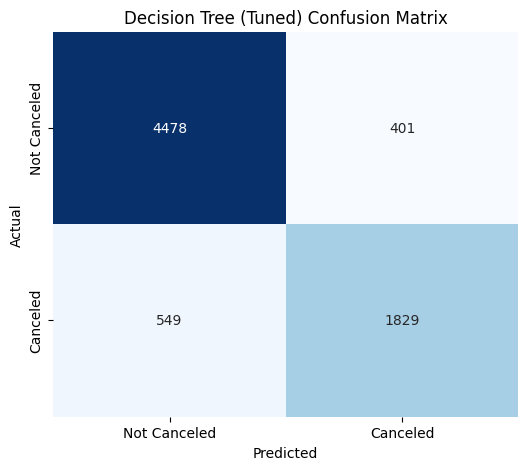



Classification Report for Decision Tree (Tuned):

              precision    recall  f1-score   support

           0       0.89      0.92      0.90      4879
           1       0.82      0.77      0.79      2378

    accuracy                           0.87      7257
   macro avg       0.86      0.84      0.85      7257
weighted avg       0.87      0.87      0.87      7257





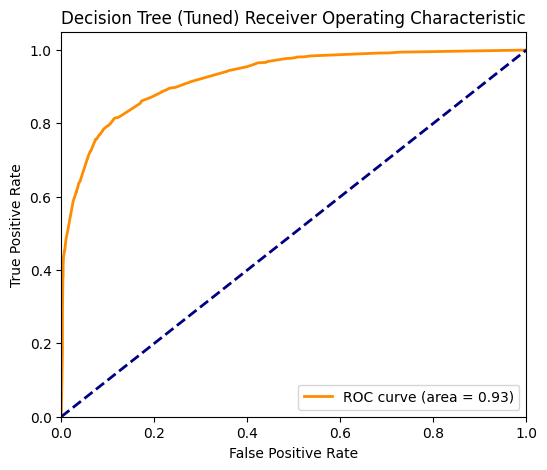

In [ ]:
# Evaluate the best Decision Tree model from GridSearchCV
evaluate_model(best_dt_model, X_test, y_test, "Decision Tree (Tuned)")

### 3. Random Forest Evaluation (Tuned Model)

Now, we evaluate the Random Forest model with its optimal hyperparameters identified through `GridSearchCV`.

### --- Random Forest (Tuned) Model Evaluation ---
Accuracy: 0.8891
Precision: 0.8633
Recall: 0.7860
F1-Score: 0.8228
ROC AUC Score: 0.9470




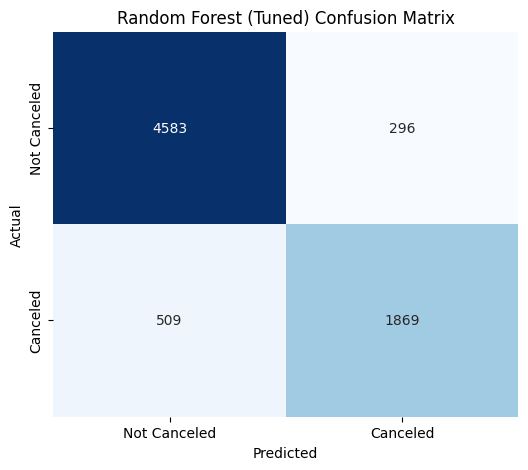



Classification Report for Random Forest (Tuned):

              precision    recall  f1-score   support

           0       0.90      0.94      0.92      4879
           1       0.86      0.79      0.82      2378

    accuracy                           0.89      7257
   macro avg       0.88      0.86      0.87      7257
weighted avg       0.89      0.89      0.89      7257





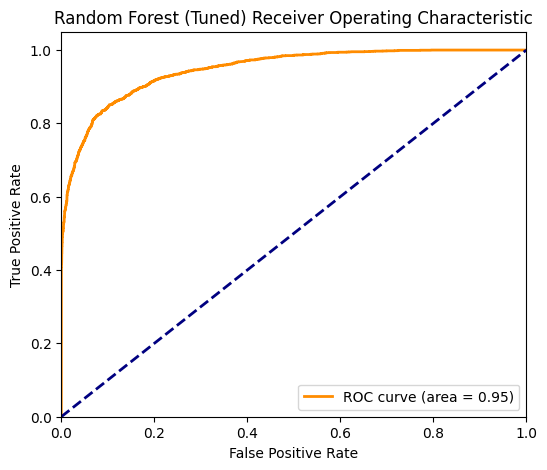

In [ ]:
# Evaluate the best Random Forest model from GridSearchCV
evaluate_model(best_rf_model, X_test, y_test, "Random Forest (Tuned)")

### 4. K-Nearest Neighbors (KNN) Evaluation (Tuned Model)

Finally, we evaluate the K-Nearest Neighbors model using the best `n_neighbors` and `weights` found via `GridSearchCV`.

### --- K-Nearest Neighbors (Tuned) Model Evaluation ---
Accuracy: 0.8780
Precision: 0.8370
Recall: 0.7796
F1-Score: 0.8073
ROC AUC Score: 0.9263




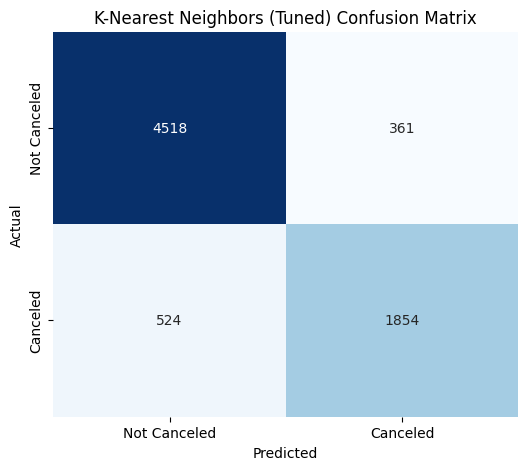



Classification Report for K-Nearest Neighbors (Tuned):

              precision    recall  f1-score   support

           0       0.90      0.93      0.91      4879
           1       0.84      0.78      0.81      2378

    accuracy                           0.88      7257
   macro avg       0.87      0.85      0.86      7257
weighted avg       0.88      0.88      0.88      7257





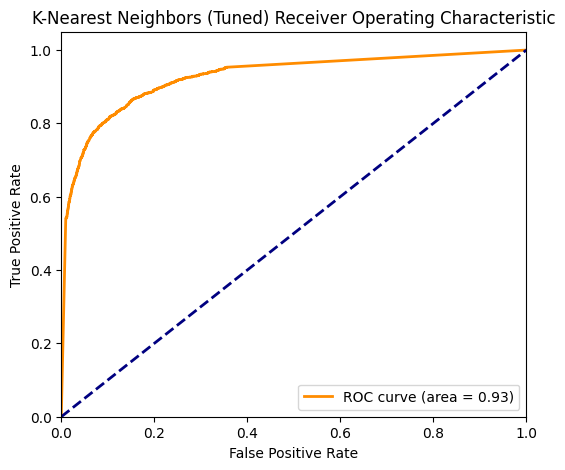

In [ ]:
evaluate_model(best_knn_model, X_test, y_test, "K-Nearest Neighbors (Tuned)")

## Section 9: Model Comparison

After training and evaluating four different classification models—Logistic Regression, Decision Tree, Random Forest, and K-Nearest Neighbors (KNN)—we now consolidate their performance metrics to determine the most suitable model for our booking prediction task.

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def get_metrics(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    metrics = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC AUC Score': roc_auc_score(y_test, y_proba)
    }
    return metrics

# Collect metrics for all models
metrics_lr = get_metrics(log_reg_model, X_test, y_test)
metrics_dt = get_metrics(best_dt_model, X_test, y_test)
metrics_rf = get_metrics(best_rf_model, X_test, y_test)
metrics_knn = get_metrics(best_knn_model, X_test, y_test)

# Create a dictionary to hold all metrics
all_metrics = {
    'Logistic Regression': metrics_lr,
    'Decision Tree (Tuned)': metrics_dt,
    'Random Forest (Tuned)': metrics_rf,
    'K-Nearest Neighbors (Tuned)': metrics_knn
}


## Section 10: Visualizations for Model Comparison

To further understand and compare the performance of our models, we will generate consolidated visualizations for the Confusion Matrices, ROC Curves, Feature Importance (for the best model), and an Accuracy Comparison Bar Chart.

### Consolidated Confusion Matrices

We will plot the confusion matrices for all evaluated models side-by-side to visually compare their true positive, true negative, false positive, and false negative rates.

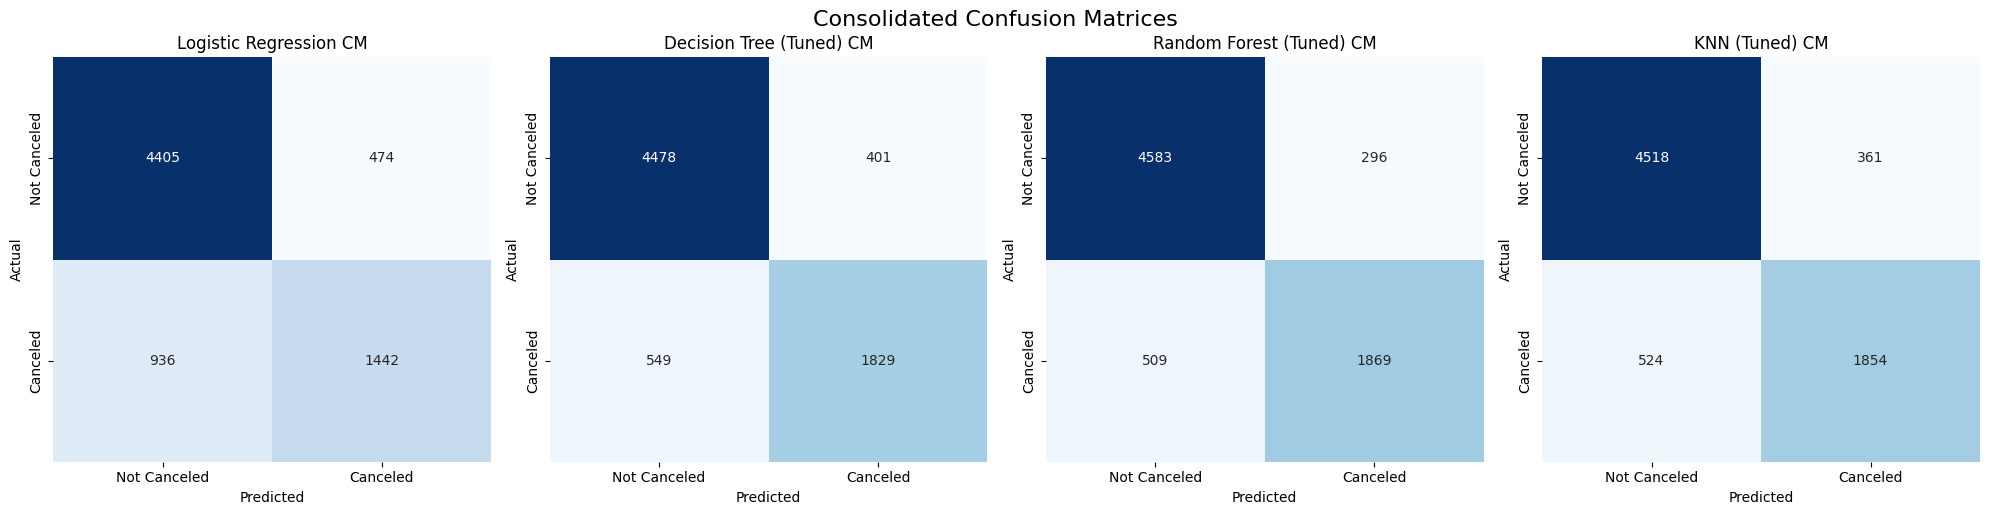

In [ ]:
from sklearn.metrics import confusion_matrix


def plot_confusion_matrix(model, X_test, y_test, model_name, ax):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Not Canceled', 'Canceled'],
                yticklabels=['Not Canceled', 'Canceled'], ax=ax)
    ax.set_title(f'{model_name} CM')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

plot_confusion_matrix(log_reg_model, X_test, y_test, "Logistic Regression", axes[0])
plot_confusion_matrix(best_dt_model, X_test, y_test, "Decision Tree (Tuned)", axes[1])
plot_confusion_matrix(best_rf_model, X_test, y_test, "Random Forest (Tuned)", axes[2])
plot_confusion_matrix(best_knn_model, X_test, y_test, "KNN (Tuned)", axes[3])

plt.tight_layout()
plt.suptitle('Consolidated Confusion Matrices', y=1.02, fontsize=16)
plt.show()

### Consolidated ROC Curves

The Receiver Operating Characteristic (ROC) curve and Area Under the Curve (AUC) are powerful tools for evaluating the performance of binary classifiers. A higher AUC indicates a better model performance in distinguishing between positive and negative classes.

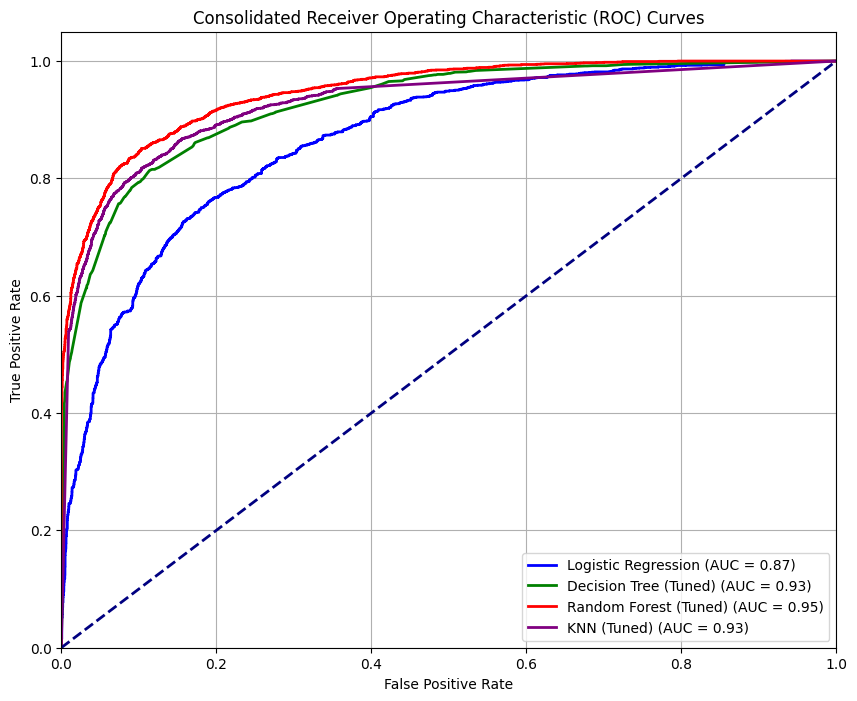

In [ ]:
from sklearn.metrics import roc_curve, auc


plt.figure(figsize=(10, 8))

# Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y_test, log_reg_model.predict_proba(X_test)[:, 1])
roc_auc_lr = auc(fpr_lr, tpr_lr)
plt.plot(fpr_lr, tpr_lr, color='blue', lw=2, label=f'Logistic Regression (AUC = {roc_auc_lr:.2f})')

# Decision Tree (Tuned)
fpr_dt, tpr_dt, _ = roc_curve(y_test, best_dt_model.predict_proba(X_test)[:, 1])
roc_auc_dt = auc(fpr_dt, tpr_dt)
plt.plot(fpr_dt, tpr_dt, color='green', lw=2, label=f'Decision Tree (Tuned) (AUC = {roc_auc_dt:.2f})')

# Random Forest (Tuned)
fpr_rf, tpr_rf, _ = roc_curve(y_test, best_rf_model.predict_proba(X_test)[:, 1])
roc_auc_rf = auc(fpr_rf, tpr_rf)
plt.plot(fpr_rf, tpr_rf, color='red', lw=2, label=f'Random Forest (Tuned) (AUC = {roc_auc_rf:.2f})')

# K-Nearest Neighbors (Tuned)
fpr_knn, tpr_knn, _ = roc_curve(y_test, best_knn_model.predict_proba(X_test)[:, 1])
roc_auc_knn = auc(fpr_knn, tpr_knn)
plt.plot(fpr_knn, tpr_knn, color='purple', lw=2, label=f'KNN (Tuned) (AUC = {roc_auc_knn:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Consolidated Receiver Operating Characteristic (ROC) Curves')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

### Feature Importance (Random Forest)

Since Random Forest was identified as the best-performing model, understanding which features it considers most important can provide valuable insights into the booking cancellation factors. Feature importances are calculated as the mean decrease in impurity caused by each feature in the trees.

/tmp/ipykernel_702/1348906827.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


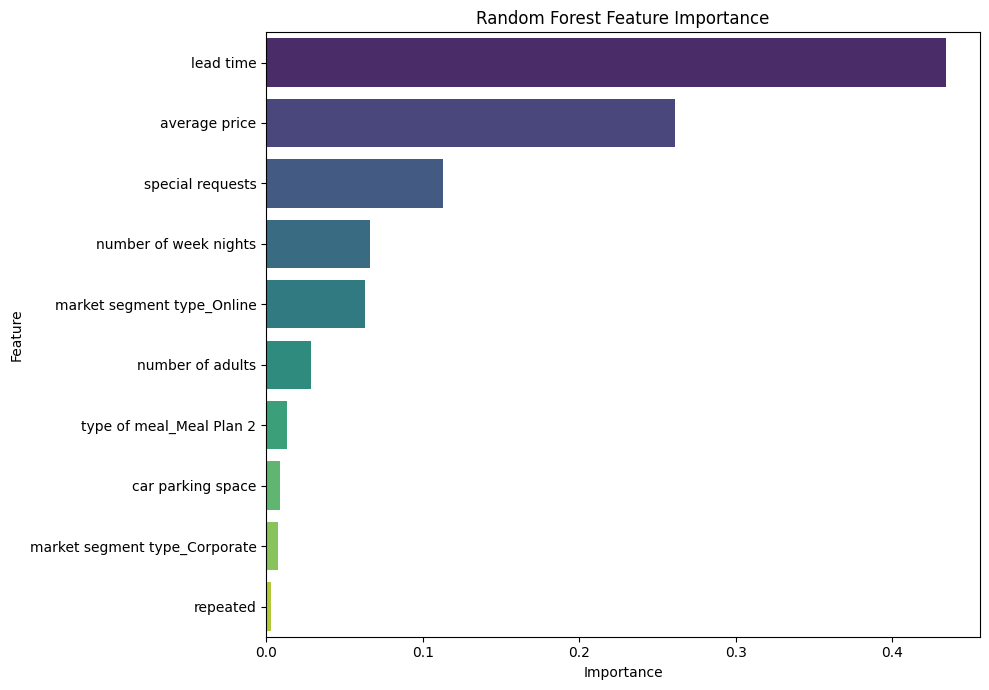

In [ ]:

importances = best_rf_model.feature_importances_
features = X_selected.columns

feature_importance_df = pd.DataFrame({'Feature': features, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 7))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### Accuracy Comparison Bar Chart

Finally, a bar chart comparing the accuracy of all models provides a quick and intuitive understanding of their relative performance.

/tmp/ipykernel_702/3244194140.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=accuracy_scores.index, y=accuracy_scores.values, palette='coolwarm')


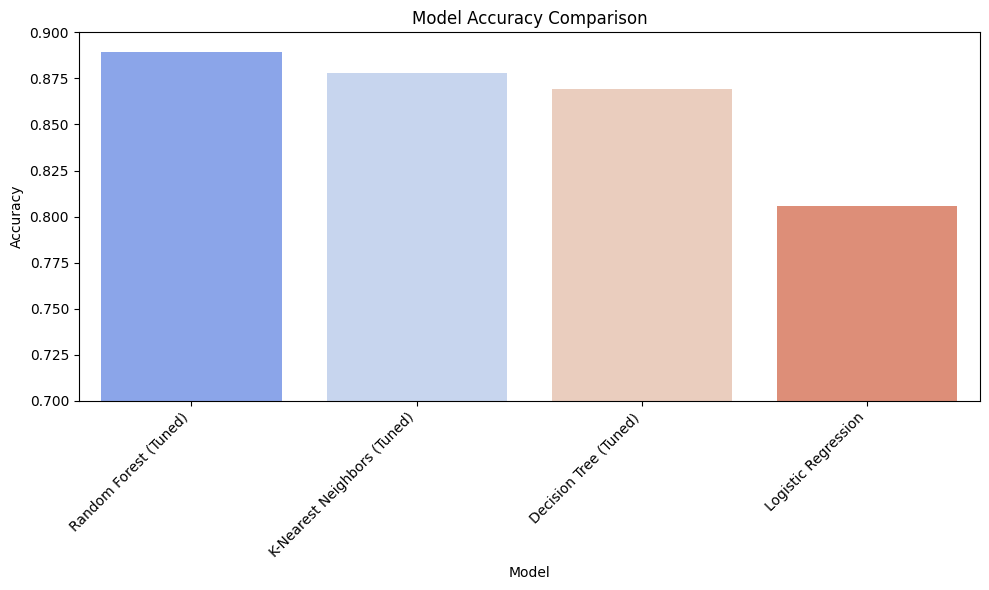

In [ ]:
accuracy_scores = metrics_df['Accuracy'].sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=accuracy_scores.index, y=accuracy_scores.values, palette='coolwarm')
plt.title('Model Accuracy Comparison')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim(0.7, 0.9) # Set y-axis limits to better highlight differences
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
metrics_df = pd.DataFrame(all_metrics).T
display(metrics_df.round(4))


,Accuracy,Precision,Recall,F1-Score,ROC AUC Score
Logistic Regression,0.8057,0.7526,0.6064,0.6716,0.8670
Decision Tree (Tuned),0.8691,0.8202,0.7691,0.7938,0.9260
Random Forest (Tuned),0.8891,0.8633,0.7860,0.8228,0.9470
K-Nearest Neighbors (Tuned),0.8780,0.8370,0.7796,0.8073,0.9263


### Model Performance as Percentages

Here are the performance metrics for each model, expressed as percentages to give a clearer view of their effectiveness:

In [ ]:
display(metrics_df.mul(100).round(2).astype(str) + '%')

,Accuracy,Precision,Recall,F1-Score,ROC AUC Score
Logistic Regression,80.57%,75.26%,60.64%,67.16%,86.7%
Decision Tree (Tuned),86.91%,82.02%,76.91%,79.38%,92.6%
Random Forest (Tuned),88.91%,86.33%,78.6%,82.28%,94.7%
K-Nearest Neighbors (Tuned),87.8%,83.7%,77.96%,80.73%,92.63%
